# Práctico 37 — Datasets y Herramientas de Audio

**Profesores:** Alain Raymond · Gabriel Sepúlveda

En este práctico van a aplicar lo que vimos en la clase: cargar audio y verlo como arreglo, trabajar con canales y sample rate, convertir formatos con `ffmpeg`, transformar audio a tensores y entrenar un clasificador de géneros musicales.

**Formato de entrega:** el archivo `.ipynb` con todas las celdas ejecutadas. Las preguntas explícitas se responden en celdas de texto; no se acepta solo el output de una celda de código como respuesta.

**Nombre alumno:**

Nota sobre los tiempos: el entrenamiento de la Parte 2 tarda del orden de 6 minutos con MFCC en GPU (y la Actividad 4 pide una segunda corrida con wav2vec, que es más lenta). Considérenlo al administrar la sesión.


# Parte 1 - Lidiando con el audio
## 0 · Preparación

Antes de partir: **Entorno de ejecución → Cambiar tipo de entorno → GPU (T4)**. La vamos a necesitar para el entrenamiento.


In [1]:
import torch
print("GPU disponible:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Vamos a usar:", device)

GPU disponible: True
Vamos a usar: cuda


In [2]:
# torchaudio es la libreria de audio de PyTorch; torchcodec es su lector de archivos.
!pip install -q torchcodec soundfile

import numpy as np
import torch
import torchaudio
import torchaudio.functional as Fa
import soundfile as sf
import matplotlib.pyplot as plt
import IPython.display as ipd
print("torch", torch.__version__, "| torchaudio", torchaudio.__version__)

torch 2.11.0+cu130 | torchaudio 2.11.0+cu130


## 1 · El audio es un arreglo de amplitudes

*(En la clase: bloque «El archivo en el disco».)*

En vez de descargar un audio, partamos fabricando uno. Un audio digital no tiene nada de especial: es un arreglo de amplitudes, una por muestra.


In [3]:
sr = 22050          # muestras por segundo
dur = 1.0           # segundos
t = np.arange(int(sr*dur)) / sr        # eje de tiempo
la440 = 0.01 * np.sin(2*np.pi*440*t)    # la nota La (440 Hz)

print("Tipo:", type(la440))
print("Forma:", la440.shape, "->", sr, "muestras por segundo x", dur, "segundos")
print("Primeras 8 amplitudes:", np.round(la440[:8], 3))

Tipo: <class 'numpy.ndarray'>
Forma: (22050,) -> 22050 muestras por segundo x 1.0 segundos
Primeras 8 amplitudes: [0.    0.001 0.002 0.004 0.005 0.006 0.007 0.008]


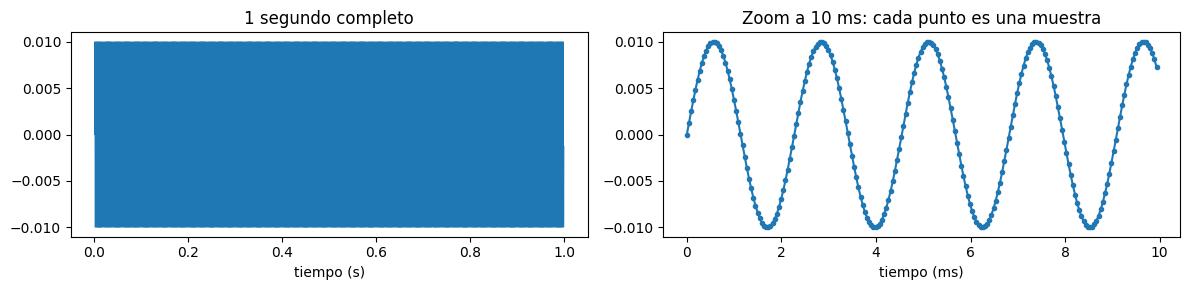

In [4]:
# El mismo diagrama de la clase, ahora con datos reales: la onda y sus muestras
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].plot(t, la440, lw=0.5); ax[0].set_title("1 segundo completo"); ax[0].set_xlabel("tiempo (s)")
zoom = slice(0, 220)   # ~10 ms
ax[1].plot(t[zoom]*1000, la440[zoom], marker="o", ms=3)
ax[1].set_title("Zoom a 10 ms: cada punto es una muestra"); ax[1].set_xlabel("tiempo (ms)")
plt.tight_layout(); plt.show()

In [5]:
# Como es solo un arreglo, se puede escuchar directo:
ipd.Audio(la440, rate=sr)

In [6]:
# Guardarlo en disco lo convierte en un archivo de audio:
sf.write("la440.wav", la440, sr, subtype="PCM_16")   # 16 bits por muestra
!ls -la la440.wav

-rw-r--r-- 1 root root 44144 Sep 24 00:31 la440.wav


Verifiquen con la fórmula de la clase: `sr × bits × canales × duración` = 22.050 × 16 × 1 × 1 = 352.800 bits ≈ 44 KB. Coincide con el tamaño del archivo.


## 2 · Canales

Un archivo estéreo son dos arreglos, uno por canal. Armemos uno con una nota distinta en cada oído.


In [7]:
mi659 = 0.8 * np.sin(2*np.pi*659.25*t)          # la nota Mi
estereo = np.stack([la440, mi659])               # forma (2, muestras)
print("Forma:", estereo.shape, "-> (canales, muestras)")

sf.write("estereo.wav", estereo.T, sr, subtype="PCM_16")  # soundfile espera (muestras, canales)
ipd.Audio(estereo, rate=sr)   # con audifonos: La a la izquierda, Mi a la derecha

Forma: (2, 22050) -> (canales, muestras)


In [8]:
# torchaudio entrega SIEMPRE (canales, muestras) como tensor, incluso en mono:
x, sr_t = torchaudio.load("estereo.wav")
print("torchaudio ->", x.shape, "| sample rate:", sr_t)
print("Promediar canales para dejar mono:", x.mean(dim=0).shape)

torchaudio -> torch.Size([2, 22050]) | sample rate: 22050
Promediar canales para dejar mono: torch.Size([22050])


## 3 · El sample rate al cargar un archivo

*(En la clase: bloque de muestreo.)*

Ahora un archivo real. Si el link fallara, usen cualquier `.wav` corto que tengan a mano.


In [9]:
!wget -q --show-progress https://freewavesamples.com/files/Woman-Laughing.wav
wav, sr2 = torchaudio.load("Woman-Laughing.wav")
print("Forma:", wav.shape, "| sample rate:", sr2, "Hz")
ipd.Audio(wav.numpy(), rate=sr2)

Woman-Laughing.wav  100%[===================>] 223.50K   511KB/s    in 0.4s    
Forma: torch.Size([2, 57173]) | sample rate: 44100 Hz


In [10]:
# El sample rate real del archivo se puede leer de su metadata:
!apt-get install -y -qq file > /dev/null
!file Woman-Laughing.wav

Woman-Laughing.wav: RIFF (little-endian) data, WAVE audio, Microsoft PCM, 16 bit, stereo 44100 Hz


El archivo está a **44.100 Hz** y torchaudio lo entrega tal cual: **nunca resamplea por su cuenta**. Cuando se necesita otra tasa, el resampleo se hace de forma explícita con `Fa.resample` — lo van a usar en un momento.

La metadata se puede leer **sin decodificar el audio**, con torchcodec (el lector que instalamos al inicio; desde torchaudio 2.9 toda la lectura y escritura de archivos vive ahí):

In [11]:
from torchcodec.decoders import AudioDecoder
print(AudioDecoder("Woman-Laughing.wav").metadata)

# Version mono en numpy, para graficar y escuchar comodo en lo que sigue:
y2 = wav.mean(dim=0).numpy()
print("y2:", y2.shape, "muestras a", sr2, "Hz")

AudioStreamMetadata:
  duration_seconds_from_header: 1.2964399092970522
  begin_stream_seconds_from_header: None
  bit_rate: 1411200
  codec: pcm_s16le
  stream_index: 0
  duration_seconds: 1.2964399092970522
  begin_stream_seconds: 0
  sample_rate: 44100
  num_channels: 2
  sample_format: s16

y2: (57173,) muestras a 44100 Hz


In [12]:
# Reproducir a otra tasa no pierde informacion, pero cambia el tono:
print("Al doble de la tasa (todo suena mas agudo y rapido):")
display(ipd.Audio(y2, rate=sr2*2))
print("A la mitad (mas grave y lento):")
display(ipd.Audio(y2, rate=int(sr2*0.5)))

Al doble de la tasa (todo suena mas agudo y rapido):


A la mitad (mas grave y lento):


### El caso del teléfono: resamplear a 8 kHz

En la clase vimos que la telefonía trabaja a 8.000 Hz, con Nyquist en 4.000 Hz. Comprobémoslo con este audio:


In [13]:
resample_rate = 8000 # Cambien esto y reduzcanlo para notar la reducción en calidad
y_tel = Fa.resample(torch.from_numpy(y2), sr2, resample_rate).numpy()
print("Original (44.1 kHz):"); display(ipd.Audio(y2, rate=sr2))
print(f"Resampleado a {resample_rate//1000} kHz:"); display(ipd.Audio(y_tel, rate=resample_rate))

Original (44.1 kHz):


Resampleado a 8 kHz:


In [14]:
# Resamplear de vuelta hacia arriba no recupera lo perdido:
y_vuelta = Fa.resample(torch.from_numpy(y_tel), resample_rate, sr2).numpy()
print("De vuelta a 44.1 kHz (la informacion sobre 4 kHz ya no esta):")
display(ipd.Audio(y_vuelta, rate=sr2))

De vuelta a 44.1 kHz (la informacion sobre 4 kHz ya no esta):


### Actividad 1

Si tengo un archivo de audio compuesto por **1.653.750 muestras** sampleado a **44.100 Hz**:
* ¿Cuántos segundos representa el archivo?
* ¿De qué tamaño debe ser la ventana para que represente 0,01 segundos?


In [15]:
#@title Actividad 1
Respuesta = '37.5s - 441' #@param ["No sé", "75s - 441", "37.5s - 441", "37.5s - 882", "75s - 882", "150s - 441", "37.5s - 4410", "75s - 4410"]

## 4 · Formatos y peso en disco

*(En la clase: «Formatos: ¿comprimir o no?» y la conversión con `ffmpeg`.)*

Convirtamos nuestro propio audio a los formatos que vimos y comparemos tamaños:


In [16]:
# ffmpeg ya viene en Colab
!ffmpeg -y -loglevel error -i Woman-Laughing.wav risa.flac
!ffmpeg -y -loglevel error -i Woman-Laughing.wav risa.mp3
!ffmpeg -y -loglevel error -i Woman-Laughing.wav risa.ogg
!ffmpeg -y -loglevel error -i Woman-Laughing.wav -c:a aac risa.m4a
!ffmpeg -y -loglevel error -i Woman-Laughing.wav -ar 16000 -ac 1 risa_16k_mono.wav
!du -h Woman-Laughing.wav risa.flac risa.mp3 risa.ogg risa.m4a risa_16k_mono.wav

224K	Woman-Laughing.wav
112K	risa.flac
24K	risa.mp3
24K	risa.ogg
24K	risa.m4a
44K	risa_16k_mono.wav


Coincide con la clase: el WAV es el más pesado, FLAC comprime sin perder información, y los lossy (mp3, ogg, m4a) son los más livianos. La última línea muestra el uso más común de `ffmpeg` en un proyecto: convertir, resamplear y dejar mono en un solo comando.

Escuchen el mp3 y el wav. Para una tarea perceptual como esta, la diferencia es mínima; es el mismo criterio que discutimos en la clase.


In [17]:
print("WAV original:"); display(ipd.Audio("Woman-Laughing.wav"))
print("MP3:"); display(ipd.Audio("risa.mp3"))

WAV original:


MP3:


### Actividad 2

De los siguientes archivos **sin comprimir**, ¿cuál ocupa más espacio en disco?

* **A:** 60 s sampleado a 60 Hz, 16 bits por muestra.
* **B:** 30 s sampleado a 120 Hz, 32 bits por muestra.
* **C:** 15 s sampleado a 120 Hz, 128 bits por muestra.
* **D:** 60 s sampleado a 60 Hz, 8 bits por muestra.


In [18]:
#@title Actividad 2
Respuesta = 'C' #@param ["No sé", "A", "B", "C", "D"]

## 5 · Transformaciones (MFCC, MEL)

*(En la clase: bloque «De archivo a tensor».)*

Hasta aquí el audio es un arreglo 1D larguísimo: decenas de miles de números por segundo, donde cada muestra por sí sola no dice casi nada. Se puede entrenar directo sobre eso, pero a los modelos les resulta mucho más fácil trabajar con las representaciones que vieron la clase pasada: el **mel spectrogram** (qué frecuencias suenan en cada instante) y los **MFCC** (un resumen todavía más compacto de esa misma información).

En torchaudio esa conversión la hacen las **transforms**: objetos que se configuran una vez y después se llaman como una función, convirtiendo el tensor de audio en el tensor de features que entra al modelo. En la Parte 2 van a ver una metida dentro del `Dataset`, trabajando en cada `__getitem__`. La teoría — STFT, escala Mel — es la de la clase 1; acá lo que queda es elegir bien los parámetros.

Y los parámetros son los que ya conocen, con su equivalente en una convolución 1D:

| Campo | Qué es | Análogo en CNN |
|---|---|---|
| `n_fft` | Cuántas muestras entran a cada FFT. Fija la **resolución en frecuencia**: se obtienen `n_fft/2 + 1` bins lineales antes de pasar a la escala Mel. | tamaño del receptive field |
| `win_length` | Largo de la ventana que efectivamente se pondera (≤ `n_fft`; si es menor, el resto se rellena con ceros). | kernel size |
| `hop_length` | Cuántas muestras avanza la ventana entre frame y frame. Fija la **resolución temporal**. | stride |
| `n_mels` | En cuántas bandas Mel se agrupan los bins de frecuencia. | canales de salida |
| `n_mfcc` | Cuántos coeficientes cepstrales se conservan tras la DCT sobre las bandas Mel (`n_mfcc ≤ n_mels`). | — |
| `center` | Si es `True`, se rellena la señal con `n_fft/2` a cada lado antes de cortar. Cambia el número de frames. | padding |


In [19]:
from torchaudio.transforms import MelSpectrogram, MFCC

y2t = torch.from_numpy(y2)
args = dict(n_fft=2048, hop_length=512, win_length=2048, center=False)
t_mel_exp  = MelSpectrogram(sample_rate=sr2, n_mels=64, **args)
t_mfcc_exp = MFCC(sample_rate=sr2, n_mfcc=20, melkwargs=dict(n_mels=64, **args))
S_mel, S_mfcc = t_mel_exp(y2t), t_mfcc_exp(y2t)
print("Audio crudo:      ", tuple(y2t.shape))
print("Mel spectrogram:  ", tuple(S_mel.shape),  "-> (n_mels, frames)")
print("MFCC:             ", tuple(S_mfcc.shape), "-> (n_mfcc, frames)")

Audio crudo:       (57173,)
Mel spectrogram:   (64, 108) -> (n_mels, frames)
MFCC:              (20, 108) -> (n_mfcc, frames)


In [20]:
# Misma transformacion, pero dejando los DEFAULTS de la libreria:
t_mel = MelSpectrogram(sample_rate=sr2, n_fft=2048, win_length=2048, n_mels=64)
x2 = torch.from_numpy(y2).unsqueeze(0)     # (1, muestras)
print("Entrada:", x2.shape, "-> Salida:", tuple(t_mel(x2).shape), " (canales, n_mels, frames)")

Entrada: torch.Size([1, 57173]) -> Salida: (1, 64, 56)  (canales, n_mels, frames)


### Cómo calcular la dimensión del tensor resultante

La salida tiene forma **(bandas, frames)**, y cada eje se calcula por separado.

**Bandas (filas):** `n_mels` para un mel spectrogram, `n_mfcc` para un MFCC. No depende del largo del audio.

**Frames (columnas):** el mismo cálculo que el output de una convolución, con `N` = número de muestras:

```
center=False (sin padding):  frames = ⌊(N − win_length) / hop_length⌋ + 1
center=True  (con padding):  frames = ⌊N / hop_length⌋ + 1
```

Verifiquemos con las dos celdas de arriba, donde `N = 57.173`:

* Primera celda — `hop_length=512`, `center=False`: `⌊(57173 − 2048)/512⌋ + 1 = 108` → salió `(64, 108)` y `(20, 108)`. Mismos frames, distintas filas: el MFCC solo cambia lo que se hace dentro de cada ventana, no cómo se corta el tiempo.
* Segunda celda — defaults de torchaudio, `hop_length = n_fft//2 = 1024` y `center=True`: `⌊57173/1024⌋ + 1 = 56` → salió `(1, 64, 56)`.

torchaudio antepone la dimensión de canales, quedando `(canales, n_mels, frames)`; con batch, `(batch, canales, n_mels, frames)`. Y para pasar de frames a segundos: cada frame avanza `hop_length / sr` segundos (con `hop=512` a 44.100 Hz, ~11,6 ms por columna).

### Actividad 3

Un archivo **monaural** sampleado a **32.768 Hz** dura **30 segundos**. Ventana de **4.096**, `hop_length` de **2.048**, **48** bins Mel, sin padding. ¿De qué tamaño queda tras aplicar MFCC?

*(De la clase: frames = ⌊(N − ventana)/hop⌋ + 1, el mismo cálculo que el output de una convolución.)*


In [21]:
#@title Actividad 3
Respuesta = '(48, 479)' #@param ["No sé", "(48, 480)", "(96, 479)", "(48, 15)", "(48, 479)", "(96, 239)", "(96, 480)"]

## 6 · Data augmentation

Antes de entrenar el modelo completo, la última herramienta del kit. Los datasets de audio etiquetados suelen ser chicos — el de la Parte 2 tiene 100 canciones por género — y un modelo con suficientes parámetros se los aprende de memoria. Como conseguir más datos casi nunca se puede, los **fabricamos**: transformamos los que tenemos de manera que suenen distinto pero **conserven la etiqueta**. Un rock 10% más rápido sigue siendo rock.

El criterio para elegir una transformación es siempre el mismo:

> ¿Esta transformación es una **invariancia real** del problema, o le estoy enseñando al modelo algo falso?

Cambiar el tono es válido para clasificar género; es destructivo si la tarea fuera detectar tonalidad o identificar al hablante, porque ahí la etiqueta *es* lo que estamos modificando.

### 6.1 · Cambiar la duración sin cambiar el tono

Reproducir más rápido sube el tono — duración y tono vienen pegados. Separarlos es el trabajo del **phase vocoder**, y la idea cabe en una asimetría: en la STFT, la **amplitud** de cada bin es información sobre el *contenido*, y la **fase** es información sobre el *reloj*. Para estirar el audio se re-temporizan las amplitudes (interpolando entre frames), pero las fases **no se copian**: se regeneran, haciendo girar cada oscilador a su velocidad propia de principio a fin. La celda siguiente muestra qué pasa si uno copia las fases en vez de regenerarlas.

In [22]:
from torchaudio.transforms import TimeStretch

def time_stretch(y_np, rate, n_fft=2048, hop=512):
    """Estira o acorta sin cambiar el tono (phase vocoder sobre la STFT)."""

    # La ventana de Hann: una campana suave de n_fft puntos. Apaga los bordes
    # de cada trozo para que el corte no meta frecuencias falsas (leakage).
    vent = torch.hann_window(n_fft)

    # 1) ANALISIS. De la onda a la STFT compleja:
    #    - torch.from_numpy(...).float(): el arreglo numpy a tensor float32.
    #    - n_fft: cuantas muestras entran a cada FFT (el largo de la ventana).
    #    - hop_length: cuanto avanza la ventana entre frame y frame.
    #    - return_complex=True: queremos magnitud Y fase (los numeros complejos
    #      completos). Sin la fase no se puede reconstruir audio.
    #    Resultado: matriz (n_fft//2 + 1 bins de frecuencia, ~len/hop frames).
    Sx = torch.stft(torch.from_numpy(y_np).float(), n_fft=n_fft, hop_length=hop,
                    window=vent, return_complex=True)

    # 2) EL PHASE VOCODER. TimeStretch re-temporiza la STFT:
    #    - interpola las magnitudes al nuevo largo (rate=0.7 -> mas frames,
    #      rate=1.5 -> menos frames),
    #    - y REGENERA las fases frame a frame en vez de copiarlas, para que
    #      cada frecuencia siga girando a su velocidad real (eso preserva el tono).
    #    - n_freq debe calzar con los bins de la STFT: n_fft//2 + 1.
    #    - fixed_rate: el factor de velocidad.
    Sy = TimeStretch(hop_length=hop, n_freq=n_fft//2 + 1, fixed_rate=rate)(Sx)

    # 3) SINTESIS. La STFT inversa pega los frames de vuelta en una onda
    #    (misma ventana y hop para que el overlap-add cierre parejo)
    #    y .numpy() la devuelve como arreglo, igual que la entrada.
    return torch.istft(Sy, n_fft=n_fft, hop_length=hop, window=vent).numpy()

y_lento  = time_stretch(y2, 0.7)   # rate < 1 -> mas lento y mas largo
y_rapido = time_stretch(y2, 1.5)   # rate > 1 -> mas rapido y mas corto

for nombre, s in [("original", y2), ("rate=0.7", y_lento), ("rate=1.5", y_rapido)]:
    print(f"{nombre:>10}: {s.shape[0]:>7} muestras = {s.shape[0]/sr2:.2f} s   (sr sigue siendo {sr2} Hz)")

print("\nOriginal:");  display(ipd.Audio(y2, rate=sr2))
print("rate=0.7 (mas lento, MISMO tono):");  display(ipd.Audio(y_lento, rate=sr2))
print("rate=1.5 (mas rapido, MISMO tono):"); display(ipd.Audio(y_rapido, rate=sr2))

  original:   57173 muestras = 1.30 s   (sr sigue siendo 44100 Hz)
  rate=0.7:   81408 muestras = 1.85 s   (sr sigue siendo 44100 Hz)
  rate=1.5:   37888 muestras = 0.86 s   (sr sigue siendo 44100 Hz)

Original:


rate=0.7 (mas lento, MISMO tono):


rate=1.5 (mas rapido, MISMO tono):


### 6.2 · Cambiar el tono sin cambiar la duración

No necesita teoría nueva, solo el truco de la cinta: reproducir al doble de velocidad sube la frecuencia **y** dura la mitad. Salvo que uno estire la cinta primero:

1. `time_stretch` al doble de largo → tono intacto, dura el doble.
2. Resamplear al doble de velocidad → vuelve al largo original, pero con la frecuencia elevada.

Esto lo hace la función de `torchaudio.functional.pitch_shift`

Todos conservan el largo: (57173,) (57173,) (57173,)


/usr/local/lib/python3.13/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (64) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


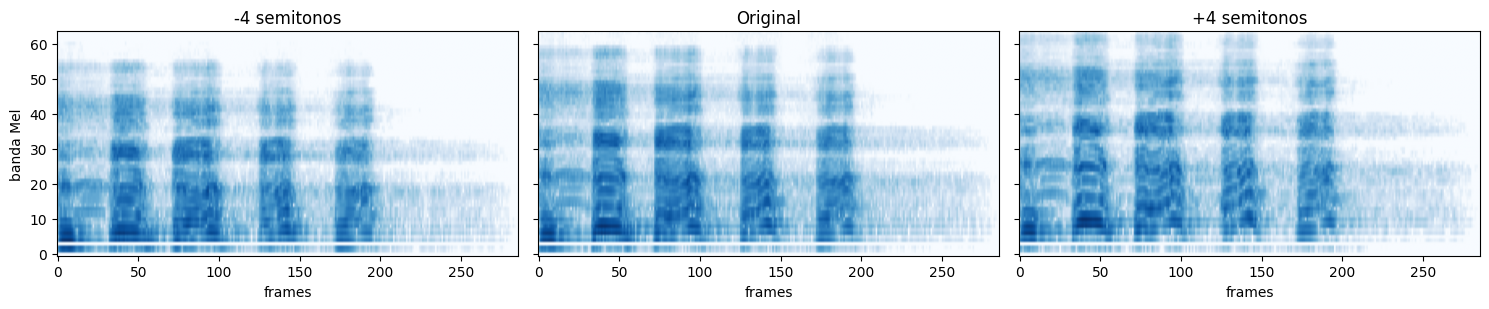

Original:


+4 semitonos (mas agudo, MISMA duracion):


-4 semitonos (mas grave, MISMA duracion):


In [23]:
y_agudo = Fa.pitch_shift(torch.from_numpy(y2), sr2, n_steps=4).numpy()    # +4 semitonos
y_grave = Fa.pitch_shift(torch.from_numpy(y2), sr2, n_steps=-4).numpy()   # -4 semitonos
print("Todos conservan el largo:", y2.shape, y_agudo.shape, y_grave.shape)

from torchaudio.transforms import MelSpectrogram, AmplitudeToDB
def mel_db(y_np, sr, n_mels=64):
    Sx = MelSpectrogram(sample_rate=sr, n_mels=n_mels)(torch.from_numpy(y_np).float())
    return AmplitudeToDB(stype="power", top_db=80)(Sx).numpy()

fig, ax = plt.subplots(1, 3, figsize=(15, 3.2), sharey=True)
for a, (s, titulo) in zip(ax, [(y_grave, "-4 semitonos"), (y2, "Original"), (y_agudo, "+4 semitonos")]):
    a.imshow(mel_db(s, sr2), origin="lower", aspect="auto", cmap="Blues")
    a.set_title(titulo); a.set_xlabel("frames")
ax[0].set_ylabel("banda Mel")
plt.tight_layout(); plt.show()

print("Original:"); display(ipd.Audio(y2, rate=sr2))
print("+4 semitonos (mas agudo, MISMA duracion):"); display(ipd.Audio(y_agudo, rate=sr2))
print("-4 semitonos (mas grave, MISMA duracion):"); display(ipd.Audio(y_grave, rate=sr2))

En el espectrograma los armónicos suben o bajan **en bloque**, manteniendo sus proporciones; el eje del tiempo queda idéntico.

**Las cuatro maneras de "acelerar" un audio, para no confundirlas nunca más:**

| Operación | Duración | Tono | Nº de muestras |
|---|---|---|---|
| Reproducir a otro `rate` (sección 3) | cambia | cambia | igual |
| `resample` | igual | igual | cambia |
| `time_stretch` | cambia | **igual** | cambia |
| `pitch_shift` | **igual** | cambia | igual |

### 6.3 · SpecAugment: aumentar sobre el espectrograma

Si conocen **Cutout** de visión por computador, esto es lo mismo sobre el espectrograma: tapar con ceros filas (frequency masking) y columnas (time masking) de ancho y posición aleatorios en cada batch.

Funciona porque es **dropout con estructura**: en vez de apagar unidades sueltas, apaga regiones contiguas. Si el modelo aprendió "es metal porque hay energía en esta banda", taparla entera lo obliga a buscar evidencia redundante en otra parte. Viene de Park et al. (2019), originalmente para reconocimiento de voz.

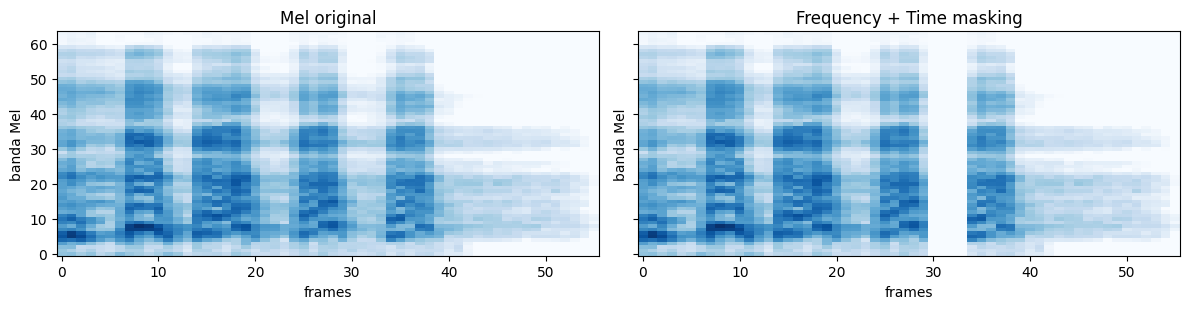

La forma no cambia: (1, 64, 56) -> (1, 64, 56)


In [24]:
from torchaudio.transforms import MelSpectrogram, AmplitudeToDB, TimeMasking, FrequencyMasking

# Mismos parametros que la celda de defaults de la sección 5:
t_mel = MelSpectrogram(sample_rate=sr2, n_fft=2048, win_length=2048, n_mels=64)

S_t = t_mel(torch.from_numpy(y2).unsqueeze(0))          # (1, n_mels, frames)
S_aug = TimeMasking(time_mask_param=25)(FrequencyMasking(freq_mask_param=12)(S_t))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2), sharey=True)
for a, (s, titulo) in zip(ax, [(S_t, "Mel original"), (S_aug, "Frequency + Time masking")]):
    a.imshow(AmplitudeToDB(stype="power", top_db=80)(s)[0].numpy(), origin="lower", aspect="auto", cmap="Blues")
    a.set_title(titulo); a.set_xlabel("frames"); a.set_ylabel("banda Mel")
plt.tight_layout(); plt.show()
print("La forma no cambia:", tuple(S_t.shape), "->", tuple(S_aug.shape))

### 6.4 · Sumar ruido: la perilla es el SNR

La augmentation más directa: sumarle una señal de fondo. El género de una canción no cambia porque suene una cafetería atrás. La pregunta es **cuánto** ruido, y se responde con la **relación señal-ruido** (SNR): el cociente entre la potencia de la señal y la del ruido — potencia = promedio de las amplitudes al cuadrado — en decibeles:

$$\text{SNR} = 10 \log_{10}\frac{P_{señal}}{P_{ruido}} \;\; \text{[dB]}$$

La imagen mental es conversar en una fiesta: la voz es la señal, el murmullo es el ruido. Para calibrar el oído:

* **20 dB**: la señal tiene 100 veces la potencia del ruido; apenas se percibe.
* **10 dB**: 10 veces; fondo claramente audible.
* **3 dB**: factor 2; el ruido casi tan fuerte como la señal.
* **0 dB o menos**: el ruido empareja o supera a la señal.

`torchaudio.functional.add_noise(señal, ruido, snr)` escala el ruido para lograr exactamente el SNR pedido. En entrenamiento el SNR se sortea en un rango (por ejemplo, entre 10 y 20 dB), así cada época suena distinto.

In [25]:
import torchaudio.functional as Fa

senal = torch.from_numpy(y2).unsqueeze(0)          # (1, N)
ruido_blanco = torch.randn_like(senal)             # ruido blanco, mismo largo

print("Original:"); display(ipd.Audio(y2, rate=sr2))
for snr_db in [20, 10, 3]:
    con_ruido = Fa.add_noise(senal, ruido_blanco, snr=torch.tensor([snr_db]))
    # Verificacion con la definicion: separamos el ruido que quedo en la mezcla
    # y calculamos 10*log10(P_senal / P_ruido). Debe dar lo que pedimos.
    ruido_resultante = con_ruido - senal
    snr_medido = 10 * torch.log10((senal**2).mean() / (ruido_resultante**2).mean())
    print(f"SNR pedido: {snr_db} dB | medido con la formula: {snr_medido:.1f} dB")
    display(ipd.Audio(con_ruido[0].numpy(), rate=sr2))

Original:


SNR pedido: 20 dB | medido con la formula: 20.0 dB


SNR pedido: 10 dB | medido con la formula: 10.0 dB


SNR pedido: 3 dB | medido con la formula: 3.0 dB


El ruido blanco es el más simple y ya regulariza, pero si el modelo va a operar con audio de la calle o de un teléfono, conviene sumar **grabaciones de ese ruido real** — misma API, solo cambia el tensor.

En la Parte 2 lo van a usar de verdad: el `collate_fn` del entrenamiento suma ruido con el SNR sorteado entre 10 y 20 dB. Dos reglas al aplicarlo (valen para cualquier augmentation):

1. **Solo a train.** Nunca a validación ni test — si no, no saben contra qué están midiendo.
2. **Distinta en cada época.** Como `add_noise` sortea ruido y SNR nuevos en cada batch, esta regla sale gratis.

Referencia: [tutorial de data augmentation de torchaudio](https://docs.pytorch.org/audio/stable/tutorials/audio_data_augmentation_tutorial.html), que además muestra cómo simular reverberación de sala (RIR) y códecs de teléfono.

# Parte 2 (Reiniciar sesión recomendado)
## 7 · Clasificación de géneros musicales con GTZAN

Aquí se junta todo. Esta parte es **autocontenida**: si vienen llegando (o se les reinició el runtime), basta correr la celda de setup siguiente y pueden partir desde acá. Vamos a entrenar el clasificador completo sobre un problema real: 1.000 canciones, 10 géneros. La noticia importante es que **es el mismo pipeline que ya conocen de las clases anteriores** — `Dataset`, `DataLoader`, modelo, loop de entrenamiento — con los matices de audio que acabamos de ver: los archivos hay que decodificarlos, los largos varían (el batching necesita ayuda), la señal cruda pasa por una transform antes de entrar al modelo, y el `collate_fn` suma ruido de fondo solo en entrenamiento. Vayan marcando dónde aparece cada uno.

La celda de features trae además un toggle: entrenar desde **MFCC** (features de fórmula, como hasta ahora) o desde los embeddings de **wav2vec 2.0** (features aprendidas; ver el anexo). Primera pasada con MFCC; la comparación es la parte opcional de la Actividad 4 — y ojo, que gane el preentrenado no está garantizado: wav2vec aprendió de habla, y esto es música.

In [26]:
# Setup minimo de esta seccion (independiente de las partes anteriores)
!pip install -q torchcodec

import torch
import torchaudio
import torchaudio.functional as Fa
import matplotlib.pyplot as plt
import IPython.display as ipd

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", device, "| torchaudio", torchaudio.__version__)

Dispositivo: cuda | torchaudio 2.11.0+cu130


In [27]:
!wget -q --show-progress https://www.dropbox.com/s/4af1tw2asd6nscu/genres.zip
!unzip -qq genres.zip

genres.zip          100%[===================>]   1.14G  16.5MB/s    in 76s     


In [28]:
from torchaudio.datasets import GTZAN
d_train = GTZAN(root=".", folder_in_archive="genres_original", subset="training")
d_val   = GTZAN(root=".", folder_in_archive="genres_original", subset="validation")
d_test  = GTZAN(root=".", folder_in_archive="genres_original", subset="testing")
ejemplo = d_train[100]
print("Un elemento del dataset:", ejemplo[0].shape, "|", ejemplo[1], "Hz |", ejemplo[2])
ipd.Audio(ejemplo[0].numpy(), rate=ejemplo[1])

Un elemento del dataset: torch.Size([1, 661794]) | 22050 Hz | country


Intentemos armar un batch directamente. Como vimos en la clase, esto falla: los audios vienen en largos distintos y PyTorch no puede apilarlos.


In [29]:
from torch.utils.data import DataLoader
data = DataLoader(d_train, batch_size=20, shuffle=True)
try:
    batch = next(iter(data))
except Exception as e:
    print("Error esperado:", type(e).__name__)
    print(str(e)[:200])

Error esperado: RuntimeError
stack expects each tensor to be equal size, but got [1, 661504] at entry 0 and [1, 661794] at entry 1


In [30]:
# La solucion es una collate_fn: corta todo al mismo largo y convierte los
# labels de texto a indices numericos. Ademas, SOLO en entrenamiento, suma
# ruido de fondo con el SNR sorteado: la augmentation de la sección 6.
GENEROS = ["blues","classical","country","disco","hiphop","jazz","metal","pop","reggae","rock"]
a_indice = {g: i for i, g in enumerate(GENEROS)}

def new_collate(batch, max_values=660000, train=False):
    samples, srs, labels = [], [], []
    for s, sr_b, label in batch:
        w = s[0][:max_values]
        if train:
            snr = torch.empty(1).uniform_(10, 20)     # ruido y SNR nuevos en cada batch
            w = Fa.add_noise(w.unsqueeze(0), torch.randn(1, w.shape[0]), snr=snr)[0]
        samples.append(w); srs.append(sr_b); labels.append(a_indice[label])
    return torch.stack(samples), torch.tensor(srs), torch.tensor(labels)

data = DataLoader(d_train, batch_size=20, shuffle=True, collate_fn=new_collate)
batch = next(iter(data))
print("Muestras:", batch[0].shape, "| Labels:", batch[2][:10])

Muestras: torch.Size([20, 660000]) | Labels: tensor([1, 8, 9, 2, 8, 1, 3, 4, 0, 8])


In [31]:
# El modelo: una GRU. Como dijimos en la clase, hoy tratamos el audio como
# secuencia; la proxima clase lo trataremos como imagen, con CNNs.
import torch.nn as nn

class ModeloRNN(nn.Module):
    def __init__(self, input_size, hidden_size=100, n_hidden_layers=2, n_classes=10):
        super().__init__()
        self.rnn = nn.GRU(input_size, hidden_size, num_layers=n_hidden_layers,
                          batch_first=True, dropout=0.5)
        self.cls = nn.Linear(hidden_size, n_classes)
    def forward(self, x):
        output, h = self.rnn(x)
        return self.cls(h[-1])

In [32]:
#@title Features: elijan la representacion de entrada
from torch.optim import Adam

FEATURES = "MFCC"  #@param ["MFCC", "wav2vec"]

if FEATURES == "MFCC":
    # Features de formula fija, como en la sección 5:
    from torchaudio.transforms import MFCC as TA_MFCC
    n_mfcc = 40
    t_mfcc = TA_MFCC(sample_rate=22050, n_mfcc=n_mfcc,
                     melkwargs={"win_length": 8192, "n_fft": 8192}).to(device)
    dim_entrada = n_mfcc

    def extraer(samples):
        return t_mfcc(samples.to(device)).permute(0, 2, 1)   # (batch, frames, n_mfcc)

else:
    # Features aprendidas: wav2vec 2.0 congelado como extractor (ver anexo).
    # Solo la GRU se entrena; el Transformer no se toca.
    bundle = torchaudio.pipelines.WAV2VEC2_BASE
    w2v = bundle.get_model().to(device).eval()
    resamp16 = torchaudio.transforms.Resample(22050, bundle.sample_rate).to(device)
    dim_entrada = 768

    def extraer(samples):
        s = samples[:, :330000].to(device)        # 15 s bastan y alivian la memoria de la T4
        with torch.no_grad():
            feats, _ = w2v.extract_features(resamp16(s))
        # Capa intermedia, no la ultima: para tareas que no son reconocimiento de voz,
        # las capas del medio transfieren mejor (la final esta especializada en el
        # objetivo de preentrenamiento). Y submuestreamos 1 de cada 4 frames para que
        # la secuencia quede de un largo comparable al de los MFCC (~190 vs ~160 pasos);
        # a la GRU le cuesta con secuencias de 750 pasos.
        return feats[6][:, ::4]                   # (batch, frames de ~80 ms, 768)

def test(model, loader):
    model.eval(); correct = total = 0
    with torch.no_grad():
        for samples, srs, labels in loader:
            preds = model(extraer(samples)).argmax(dim=1)
            correct += (preds == labels.to(device)).sum().item()
            total += len(labels)
    model.train(); return correct / total

print("Entrenando desde:", FEATURES, "| dimension de entrada a la GRU:", dim_entrada)

Entrenando desde: MFCC | dimension de entrada a la GRU: 40


In [33]:
# Entrenamiento: 10 epocas. Con MFCC tarda ~6 minutos en GPU T4; con
# wav2vec cada epoca es mas lenta (el Transformer corre en cada batch).
model = ModeloRNN(dim_entrada).to(device)
loss_function = nn.CrossEntropyLoss()
opt = Adam(model.parameters(), lr=1e-4)

# El ruido va SOLO en el loader de train; el de test queda limpio para que
# la metrica sea comparable entre epocas.
train_loader = DataLoader(d_train, batch_size=20, shuffle=True,
                          collate_fn=lambda b: new_collate(b, train=True))
bs_test = 100 if FEATURES == "MFCC" else 20   # wav2vec no aguanta batch 100 en la T4
test_loader  = DataLoader(d_test, batch_size=bs_test, shuffle=False, collate_fn=new_collate)

n_epochs = 10
historial = []
for epoch in range(n_epochs):
    total_loss = 0.0
    for samples, srs, labels in train_loader:
        loss = loss_function(model(extraer(samples)), labels.to(device))
        opt.zero_grad(); loss.backward(); opt.step()
        total_loss += loss.item()
    acc = test(model, test_loader)
    historial.append(acc)
    print(f"Epoca {epoch+1:02d}/{n_epochs} | loss {total_loss/len(train_loader):.3f} | acc test {acc:.2%}")

Epoca 01/10 | loss 2.308 | acc test 9.66%
Epoca 02/10 | loss 2.281 | acc test 10.69%
Epoca 03/10 | loss 2.289 | acc test 13.10%
Epoca 04/10 | loss 2.252 | acc test 13.79%
Epoca 05/10 | loss 2.243 | acc test 16.55%
Epoca 06/10 | loss 2.219 | acc test 15.17%
Epoca 07/10 | loss 2.202 | acc test 11.72%
Epoca 08/10 | loss 2.190 | acc test 12.41%
Epoca 09/10 | loss 2.162 | acc test 12.07%
Epoca 10/10 | loss 2.142 | acc test 11.38%


Accuracy final en TRAIN: 33.18%
Accuracy final en TEST:  11.38%


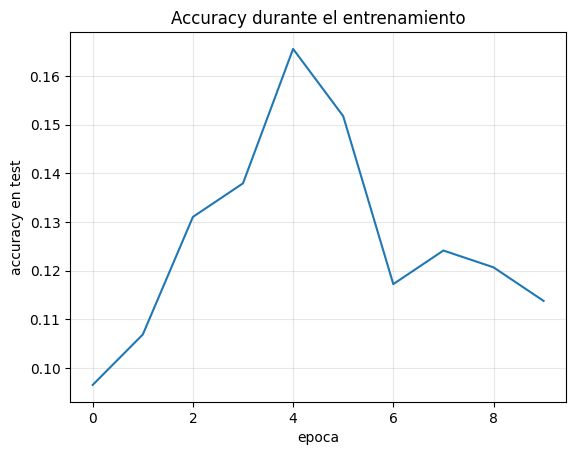

In [34]:
acc_final = test(model, test_loader)
acc_train = test(model, train_loader)
print(f"Accuracy final en TRAIN: {acc_train:.2%}")
print(f"Accuracy final en TEST:  {acc_final:.2%}")
plt.plot(historial); plt.xlabel("epoca"); plt.ylabel("accuracy en test"); plt.grid(alpha=0.3)
plt.title("Accuracy durante el entrenamiento"); plt.show()

### Actividad 4

Entrenen el modelo por 10 épocas y **reporten sus resultados**: ¿cómo es el rendimiento en el set de entrenamiento y en el de test? ¿Hay sobreajuste? ¿Qué señales lo indican?

Luego cambien el toggle a `FEATURES = "wav2vec"` y reentrenen (bastan 10 épocas). ¿Mejora o empeora respecto de los MFCC? Antes de responder, consideren con qué datos se preentrenó wav2vec 2.0 (audiolibros en inglés) y qué es lo que sus embeddings aprendieron a distinguir. ¿Esperarían el mismo resultado si la tarea fuera transcribir llamadas a texto?

**Respuesta:** En la época 10, el modelo de MFCC alcanzó un accuracy de 33.18% en el conjunto de entrenamiento, mientras que en el conjunto de test obtuvo un 11.38%. Esta diferencia de aproximadamente 22 puntos porcentuales entre ambos conjuntos sugiere sobreajuste. Esto indica que el modelo está aprendiendo y memorizando patrones específicos del conjunto de entrenamiento que son inútiles para generalizar adecuadamente a datos nuevos.

### Con wav2vec

In [58]:
# Escribir código acá
FEATURES = "wav2vec"  #@param ["MFCC", "wav2vec"]

if FEATURES == "MFCC":
    # Features de formula fija, como en la sección 5:
    from torchaudio.transforms import MFCC as TA_MFCC
    n_mfcc = 40
    t_mfcc = TA_MFCC(sample_rate=22050, n_mfcc=n_mfcc,
                     melkwargs={"win_length": 8192, "n_fft": 8192}).to(device)
    dim_entrada = n_mfcc

    def extraer(samples):
        return t_mfcc(samples.to(device)).permute(0, 2, 1)   # (batch, frames, n_mfcc)

else:
    # Features aprendidas: wav2vec 2.0 congelado como extractor (ver anexo).
    # Solo la GRU se entrena; el Transformer no se toca.
    bundle = torchaudio.pipelines.WAV2VEC2_BASE
    w2v = bundle.get_model().to(device).eval()
    resamp16 = torchaudio.transforms.Resample(22050, bundle.sample_rate).to(device)
    dim_entrada = 768

    def extraer(samples):
        s = samples[:, :330000].to(device)        # 15 s bastan y alivian la memoria de la T4
        with torch.no_grad():
            feats, _ = w2v.extract_features(resamp16(s))
        # Capa intermedia, no la ultima: para tareas que no son reconocimiento de voz,
        # las capas del medio transfieren mejor (la final esta especializada en el
        # objetivo de preentrenamiento). Y submuestreamos 1 de cada 4 frames para que
        # la secuencia quede de un largo comparable al de los MFCC (~190 vs ~160 pasos);
        # a la GRU le cuesta con secuencias de 750 pasos.
        return feats[6][:, ::4]                   # (batch, frames de ~80 ms, 768)

def test(model, loader):
    model.eval(); correct = total = 0
    with torch.no_grad():
        for samples, srs, labels in loader:
            preds = model(extraer(samples)).argmax(dim=1)
            correct += (preds == labels.to(device)).sum().item()
            total += len(labels)
    model.train(); return correct / total

print("Entrenando desde:", FEATURES, "| dimension de entrada a la GRU:", dim_entrada)

Entrenando desde: wav2vec | dimension de entrada a la GRU: 768


In [59]:
model = ModeloRNN(dim_entrada).to(device)
loss_function = nn.CrossEntropyLoss()
opt = Adam(model.parameters(), lr=1e-4)

# El ruido va SOLO en el loader de train; el de test queda limpio para que
# la metrica sea comparable entre epocas.
train_loader = DataLoader(d_train, batch_size=20, shuffle=True,
                          collate_fn=lambda b: new_collate(b, train=True))
bs_test = 100 if FEATURES == "MFCC" else 20   # wav2vec no aguanta batch 100 en la T4
test_loader  = DataLoader(d_test, batch_size=bs_test, shuffle=False, collate_fn=new_collate)

n_epochs = 10
historial = []
for epoch in range(n_epochs):
    total_loss = 0.0
    for samples, srs, labels in train_loader:
        loss = loss_function(model(extraer(samples)), labels.to(device))
        opt.zero_grad(); loss.backward(); opt.step()
        total_loss += loss.item()
    acc = test(model, test_loader)
    historial.append(acc)
    print(f"Epoca {epoch+1:02d}/{n_epochs} | loss {total_loss/len(train_loader):.3f} | acc test {acc:.2%}")

Epoca 01/10 | loss 2.307 | acc test 11.72%
Epoca 02/10 | loss 2.274 | acc test 17.59%
Epoca 03/10 | loss 2.261 | acc test 19.66%
Epoca 04/10 | loss 2.232 | acc test 22.41%
Epoca 05/10 | loss 2.207 | acc test 24.83%
Epoca 06/10 | loss 2.166 | acc test 27.93%
Epoca 07/10 | loss 2.124 | acc test 29.66%
Epoca 08/10 | loss 2.075 | acc test 29.66%
Epoca 09/10 | loss 2.026 | acc test 29.66%
Epoca 10/10 | loss 1.974 | acc test 31.72%


Accuracy final en TRAIN: 41.31%
Accuracy final en TEST:  31.72%


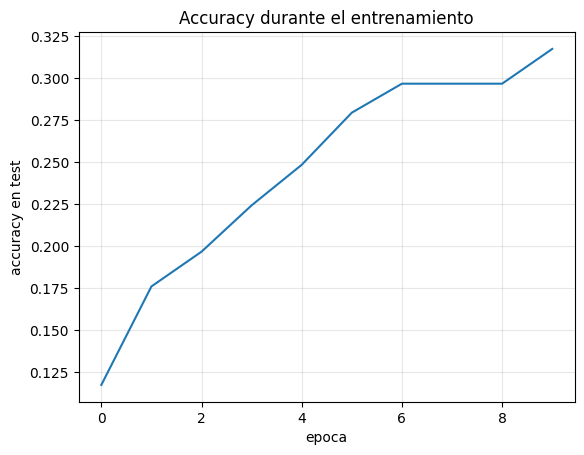

In [60]:
acc_final = test(model, test_loader)
acc_train = test(model, train_loader)
print(f"Accuracy final en TRAIN: {acc_train:.2%}")
print(f"Accuracy final en TEST:  {acc_final:.2%}")
plt.plot(historial); plt.xlabel("epoca"); plt.ylabel("accuracy en test"); plt.grid(alpha=0.3)
plt.title("Accuracy durante el entrenamiento"); plt.show()

- Podemos ver que al usar wav2vec el rendimiento en TEST mejoró considerablemente, pasando de un accuracy de 11.38% a 31.72%. Esto es interesante, ya que el embedding de wav2vec fue entrenado con audiolibros, es decir, habla sin música. Una posible explicación es que reconocer el género de una canción también puede depender de características relacionadas con la voz y las letras. Por ejemplo, el country podría tener ciertas entonaciones o patrones vocales que el embedding logra capturar, incluso sin haber sido entrenado específicamente con música.

- Si usáramos estos embeddings para transcribir llamadas de voz, esperaría un rendimiento aún mejor en TEST, ya que las llamadas se parecen mucho más a los datos con los que se entrenó wav2vec. Por lo tanto, es posible que los embeddings capturen características que sean especialmente útiles para esta tarea.

### Opcional: WAV2Vec en SpeechCommands

 Probemos ahora WAV2Vec con **Speech Commands** (está en `torchaudio.datasets`): 65.000 clips de 1 segundo, una palabra por clip, a 16 kHz — la tasa nativa de wav2vec, ni resampleo necesita. Usamos 10 palabras, "yes" y "no" incluidas.

La celda entrena el **mismo modelo** con las dos representaciones y compara. Ojo: la descarga son ~2,3 GB (una vez).

In [36]:
#@title Opcional: MFCC vs wav2vec en habla (Speech Commands, ~2.3 GB, ~6 min)
from torchaudio.datasets import SPEECHCOMMANDS
from torchaudio.transforms import MFCC as TA_MFCC
from torch.utils.data import Subset

sc_train_full = SPEECHCOMMANDS(".", download=True, subset="training")
sc_test_full  = SPEECHCOMMANDS(".", download=True, subset="testing")

PALABRAS = ["yes","no","up","down","left","right","on","off","stop","go"]
a_idx = {p: i for i, p in enumerate(PALABRAS)}
SR_SC, LARGO_SC = 16000, 16000                    # clips de 1 s

def filtrar(ds, cupo):
    """Indices de los primeros `cupo` clips por palabra (sin cargar el audio)."""
    idxs, cuenta = [], {p: 0 for p in PALABRAS}
    for i in range(len(ds)):
        label = ds.get_metadata(i)[2]
        if label in cuenta and cuenta[label] < cupo:
            idxs.append(i); cuenta[label] += 1
        if all(v >= cupo for v in cuenta.values()):
            break
    return idxs

tr_idx, te_idx = filtrar(sc_train_full, 300), filtrar(sc_test_full, 60)
print(f"{len(tr_idx)} clips de train, {len(te_idx)} de test, {len(PALABRAS)} palabras\n")

def collate_sc(train):
    def collate(batch):
        xs, ys = [], []
        for w, sr_b, label, *_ in batch:
            x = torch.nn.functional.pad(w[0], (0, max(0, LARGO_SC - w.shape[1])))[:LARGO_SC]
            if train:                              # misma augmentation que en GTZAN
                snr = torch.empty(1).uniform_(10, 20)
                x = Fa.add_noise(x.unsqueeze(0), torch.randn(1, LARGO_SC), snr=snr)[0]
            xs.append(x); ys.append(a_idx[label])
        return torch.stack(xs), torch.tensor(ys)
    return collate

loader_tr = DataLoader(Subset(sc_train_full, tr_idx), batch_size=64, shuffle=True,  collate_fn=collate_sc(True))
loader_te = DataLoader(Subset(sc_test_full,  te_idx), batch_size=64, shuffle=False, collate_fn=collate_sc(False))

t_mfcc16 = TA_MFCC(sample_rate=SR_SC, n_mfcc=40,
                   melkwargs={"win_length": 400, "n_fft": 512, "hop_length": 160}).to(device)
w2v_sc = torchaudio.pipelines.WAV2VEC2_BASE.get_model().to(device).eval()

def extraer_sc(x, modo):
    x = x.to(device)
    if modo == "MFCC":
        return t_mfcc16(x).permute(0, 2, 1)        # (batch, ~101 frames, 40)
    with torch.no_grad():
        feats, _ = w2v_sc.extract_features(x)      # ya esta a 16 kHz
    return feats[6]                                # (batch, ~49 frames, 768)

def correr(modo, n_epochs=5):
    m = ModeloRNN(40 if modo == "MFCC" else 768).to(device)
    opt_, lossf = Adam(m.parameters(), lr=1e-3), nn.CrossEntropyLoss()
    for ep in range(n_epochs):
        for x, y in loader_tr:
            loss = lossf(m(extraer_sc(x, modo)), y.to(device))
            opt_.zero_grad(); loss.backward(); opt_.step()
    m.eval(); ok = tot = 0
    with torch.no_grad():
        for x, y in loader_te:
            ok += (m(extraer_sc(x, modo)).argmax(1) == y.to(device)).sum().item()
            tot += len(y)
    return ok / tot

for modo in ["MFCC", "wav2vec"]:
    print(f"{modo:>8}: accuracy en test = {correr(modo):.2%}")

100%|██████████| 2.26G/2.26G [01:58<00:00, 20.4MB/s]


3000 clips de train, 600 de test, 10 palabras



/usr/local/lib/python3.13/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (257) may be set too low.
  warnings.warn(


Downloading: "https://download.pytorch.org/torchaudio/models/wav2vec2_fairseq_base_ls960.pth" to /root/.cache/torch/hub/checkpoints/wav2vec2_fairseq_base_ls960.pth


100%|██████████| 360M/360M [00:01<00:00, 250MB/s] 


    MFCC: accuracy en test = 45.67%
 wav2vec: accuracy en test = 86.83%


Mismo modelo, mismas épocas, misma augmentation: lo único que cambió es la representación de entrada — y el dominio de la tarea. La comparación entre este resultado y el de GTZAN es la respuesta a la pregunta opcional de la Actividad 4.

## Anexo · Referencia rápida de torchaudio

Lo que se usa el 90% del tiempo. torchaudio trabaja con tensores, corre en GPU y se integra directo al `DataLoader`; sus transforms son módulos de PyTorch, así que se mandan a GPU con `.to(device)` igual que un modelo.

### Cargar, guardar, inspeccionar

```python
x, sr = torchaudio.load(f)                      # SIEMPRE (canales, muestras); respeta el sr del archivo
x, sr = torchaudio.load(f, frame_offset=..., num_frames=...)   # cargar solo un trozo
AudioDecoder(f).metadata                        # metadata sin decodificar (from torchcodec.decoders import AudioDecoder)
torchaudio.save(f, x, sr)                       # espera (canales, muestras)
sf.write(f, y, sr)                              # para numpy; espera (muestras, canales), por eso el .T de la sección 2
```

Ojo con las **formas**: torchaudio siempre entrega `(canales, muestras)`, incluso en mono → `(1, N)`. Un `x[0]` o un `x.mean(dim=0)` a tiempo evita sorpresas.

### Operaciones básicas

```python
Fa.resample(x, 44100, 16000)                    # funcional, para un caso puntual
torchaudio.transforms.Resample(44100, 16000)    # objeto: precalcula el filtro, conviene si se reusa
x.mean(dim=0, keepdim=True)                     # a mono
x / x.abs().max()                               # normalizar el maximo a 1.0
Fa.preemphasis(x, coeff=0.97)                   # realza agudos, tipico antes de MFCC
Fa.vad(x, sample_rate=sr)                       # recorta el silencio inicial
```

### Features

```python
from torchaudio.transforms import Spectrogram, MelSpectrogram, MFCC, AmplitudeToDB
Spectrogram(n_fft=2048, hop_length=512)         # magnitud; power=None entrega el complejo
MelSpectrogram(sample_rate=sr, n_fft=2048, hop_length=512, n_mels=64)
MFCC(sample_rate=sr, n_mfcc=20, melkwargs=dict(n_fft=2048, hop_length=512, n_mels=64))
AmplitudeToDB(stype="power", top_db=80)         # a decibeles, para graficar
```

**Defaults que muerden** (ver la sección de cálculo de dimensiones): `hop_length = n_fft // 2` y `center=True` (con padding). Si el número de frames no les cuadra, revisen ahí primero.

### Data augmentation (útil para la tarea)

```python
Fa.add_noise(x, ruido, snr=torch.tensor([10]))  # suma ruido a un SNR dado, en dB
Fa.pitch_shift(x, sr, n_steps=4)                # cambia tono, conserva duracion (lento: ~1 s por archivo)
torchaudio.transforms.TimeStretch(...)          # cambia duracion, conserva tono (opera sobre la STFT compleja)
torchaudio.transforms.FrequencyMasking(freq_mask_param=12)   # SpecAugment
torchaudio.transforms.TimeMasking(time_mask_param=25)
```

### Visualizar y escuchar

```python
plt.plot(x[0].numpy())                                         # la forma de onda
plt.imshow(S_db, origin="lower", aspect="auto", cmap="Blues")  # el espectrograma es una imagen
ipd.Audio(x.numpy(), rate=sr)                                  # reproducir en el notebook
```

### ffmpeg desde la notebook

```python
!ffmpeg -i entrada.mp4 salida.wav               # extraer el audio de un video
!ffmpeg -i nota.opus -ar 16000 -ac 1 nota.wav   # convertir + resamplear + dejar mono
```

### Errores frecuentes

* Asumir que la salida es 1D: siempre es `(canales, muestras)`.
* Calcular frames con la fórmula de `center=False` cuando el default es `True`.
* Poner `pitch_shift` o `TimeStretch` dentro del `__getitem__`: son caras, se precalculan offline, una vez, y se guardan a disco.
* Aplicar augmentation a validación o test: solo a train, y distinta en cada época.

## Anexo · Embeddings preentrenados: wav2vec 2.0

Hasta aquí las features (MFCC, mel) se calcularon con fórmulas fijas. La alternativa moderna: **wav2vec 2.0**, un Transformer entrenado con miles de horas de audio *sin etiquetar* (enmascara trozos y aprende a adivinarlos, como BERT). Entrega un vector de 768 dimensiones por cada ~20 ms — un reemplazo *aprendido* de los MFCC — y encima basta un clasificador chico con pocos datos propios.

Los pesos son públicos y vienen en `torchaudio.pipelines`. Dos cosas para tener presentes: los modelos esperan audio a **16 kHz** (`bundle.sample_rate`), y la primera llamada descarga ~360 MB.

In [37]:
# El audio de la Parte 1; se recarga si vienen con la sesion reiniciada:
import os
if "y2" not in dir():
    if not os.path.exists("Woman-Laughing.wav"):
        !wget -q https://freewavesamples.com/files/Woman-Laughing.wav
    wav, sr2 = torchaudio.load("Woman-Laughing.wav")
    y2 = wav.mean(dim=0).numpy()

bundle = torchaudio.pipelines.WAV2VEC2_BASE          # ~360 MB, se descarga una vez
w2v = bundle.get_model().to(device).eval()

# El modelo espera 16 kHz: resampleo explicito, como siempre
y16 = Fa.resample(torch.from_numpy(y2), sr2, bundle.sample_rate).unsqueeze(0).to(device)
with torch.no_grad():
    feats, _ = w2v.extract_features(y16)
print(f"{len(feats)} capas de Transformer")
print(f"Ultima capa: {tuple(feats[-1].shape)}  -> (batch, frames de ~20 ms, 768 dims)")

12 capas de Transformer
Ultima capa: (1, 64, 768)  -> (batch, frames de ~20 ms, 768 dims)


El mismo audio que como MFCC era `(20, frames)` ahora es una secuencia de vectores de 768 dimensiones que ya *saben* de audio. Y hay variantes afinadas para transcribir, **incluso en español** — para el call center, esto es transcribir llamadas sin entrenar nada:

In [38]:
# Transcripcion en espanol con VoxPopuli (descomenten; descarga ~360 MB mas).
# Prueben con cualquier wav propio donde hablen en espanol:
# bundle_es = torchaudio.pipelines.VOXPOPULI_ASR_BASE_10K_ES
# asr = bundle_es.get_model().to(device).eval()
# wav_es, sr_es = torchaudio.load("mi_audio.wav")
# x = Fa.resample(wav_es.mean(0, keepdim=True), sr_es, bundle_es.sample_rate).to(device)
# with torch.no_grad():
#     emision, _ = asr(x)
#
# def ctc_greedy(em, labels):
#     out, prev = [], None
#     for i in em.argmax(-1).tolist():
#         if i != prev and labels[i] != "-":
#             out.append(" " if labels[i] == "|" else labels[i])
#         prev = i
#     return "".join(out)
#
# print(ctc_greedy(emision[0], bundle_es.get_labels()))

## Anexo · Datasets de audio (material de apoyo)

Esta sección **no se revisa durante el laboratorio**: queda como referencia para explorar por su cuenta, con los mismos datasets que vimos en la clase.

### UrbanSound8K: sonidos urbanos


In [39]:
!wget -q --show-progress https://www.dropbox.com/s/l1nq8ylb1ovepja/UrbanSound8KSplit.tar.gz
!tar -xzf UrbanSound8KSplit.tar.gz

UrbanSound8KSplit.t 100%[===================>]   5.61G  22.8MB/s    in 4m 56s  


In [40]:
son, sr_u = torchaudio.load("/content/UrbanSound8KSplit/test/audio/fold9/62567-5-0-6.wav")
print("Forma:", son.shape, "| sr:", sr_u)
ipd.Audio(son.numpy(), rate=sr_u)

Forma: torch.Size([2, 176400]) | sr: 44100


In [41]:
# La metadata indica la clase de cada clip. Observen el balance entre clases:
import pandas as pd
meta = pd.read_csv("/content/UrbanSound8KSplit/test/metadata/UrbanSound8K.csv")
print(meta["class"].value_counts())
meta.head()

class
drilling            223
street_music        214
engine_idling       208
air_conditioner     197
dog_bark            197
children_playing    192
jackhammer          185
siren               171
gun_shot             86
car_horn             74
Name: count, dtype: int64


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,62567-5-0-6.wav,62567,3.000000,7.000000,1,9,5,engine_idling
1,165166-8-0-3.wav,165166,2.333454,6.333454,1,10,8,siren
2,135527-6-14-7.wav,135527,51.906976,55.906976,2,7,6,gun_shot
3,148463-7-2-1.wav,148463,217.072451,221.072451,2,4,7,jackhammer
4,147672-3-2-0.wav,147672,3.781219,4.161808,1,2,3,dog_bark


### LibriSpeech: habla transcrita

El dataset completo son decenas de GB. Para explorar basta el split `dev-clean` (~340 MB):


In [42]:
from torchaudio.datasets import LIBRISPEECH
val_data = LIBRISPEECH(".", "dev-clean", download=True)
print("Ejemplos en dev-clean:", len(val_data))

100%|██████████| 322M/322M [00:27<00:00, 12.4MB/s] 


Ejemplos en dev-clean: 2703


In [43]:
tensor_data, sr_l, transcript, *resto = val_data[0]
print("Tensor:", tensor_data.shape, "| sr:", sr_l, "Hz")
print("Transcript:", transcript)
ipd.Audio(tensor_data.numpy(), rate=sr_l)

Tensor: torch.Size([1, 93680]) | sr: 16000 Hz
Transcript: MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL


In [44]:
# La metadata de hablantes incluye genero y minutos por persona:
!head -n 20 /content/LibriSpeech/SPEAKERS.TXT

; Some pipe(|) separated metadata about all LibriVox readers, whose work was used
; in the corpus.
;
; The meaning of the fields in left-to-right order is as follows:
;
; reader_id: the ID of the reader in the LibriVox's database
; gender: 'F' for female, 'M' for male
; subset: the corpus subset to which the reader's audio is assigned
; duration: total number of minutes of speech by the reader, included in the corpus
; name: the name under which the reader is registered in LibriVox
;
;ID  |SEX| SUBSET           |MINUTES| NAME
14   | F | train-clean-360  | 25.03 | Kristin LeMoine
16   | F | train-clean-360  | 25.11 | Alys AtteWater
17   | M | train-clean-360  | 25.04 | Gord Mackenzie
19   | F | train-clean-100  | 25.19 | Kara Shallenberg
20   | F | train-other-500  | 30.07 | Gesine
22   | F | train-clean-360  | 25.14 | Michelle Crandall
23   | F | train-clean-360  | 25.23 | Anita Roy Dobbs
25   | M | train-other-500  | 30.16 | John Gonzalez


### MusicNet: etiquetas alineadas nota a nota

Entre descarga y descompresión tarda unos 20 minutos, por eso no es parte de la sesión. Sus etiquetas están alineadas en el tiempo (cada nota, con su instrumento, ubicada al sample) y el final de los archivos es silencio sin anotar: la metadata no siempre cubre todo el audio.


In [45]:
# Descomenten para correr (~20 min):
# !wget -q https://www.dropbox.com/sh/xay56y5k6z1yous/AAD5jp3I_768-ZEFHD5MCa5pa
# !unzip -qq AAD5jp3I_768-ZEFHD5MCa5pa && cat musicnet.tar.gz.* > musicnet.tar.gz && tar -xzf musicnet.tar.gz
# sound, sr_m = torchaudio.load("musicnet/test_data/1819.wav")
# !head musicnet/test_labels/1819.csv

### Los datasets que trae torchaudio

`torchaudio.datasets` ofrece varios datasets listos para usar, con descarga y parsing incluidos — GTZAN y LibriSpeech, que ya usamos, vienen de ahí. La lista completa está en la [documentación](https://docs.pytorch.org/audio/stable/datasets.html); los principales:

* **CMUARCTIC** ([festvox.org/cmu_arctic](http://www.festvox.org/cmu_arctic/)): dataset de voces con 1.150 muestras de textos cortos elegidos de escritos sin copyright del Proyecto Gutenberg, leídos por profesionales de distintos géneros. En inglés.
* **COMMONVOICE** ([commonvoice.mozilla.org](https://commonvoice.mozilla.org/es)): dataset open source y multilingüe de voces; cada entrada es un mp3 con su transcripción, y muchas traen metadatos de edad, género y acento. **Disponible en español**, hoy con más de 500 horas validadas. Ojo: la clase de torchaudio ya no descarga por sí sola — Mozilla pide registrarse en su sitio y el dataset se baja manualmente.
* **GTZAN** ([marsyas.info](http://marsyas.info/downloads/datasets.html)): 1.000 canciones de 30 segundos cada una; 10 géneros musicales con 100 muestras por género. Muestreadas a 22.050 Hz mono, 16 bits, en formato .wav.
* **LIBRITTS** ([openslr.org/60](http://www.openslr.org/60/)): voces en inglés con múltiples hablantes, ~585 horas de personas leyendo textos, muestreado a 24 kHz. Pensado para investigación en Text-to-Speech (TTS). Es un subconjunto de LibriSpeech.
* **LJSPEECH** ([keithito.com/LJ-Speech-Dataset](https://keithito.com/LJ-Speech-Dataset)): dominio público; 13.100 archivos cortos de una sola oradora leyendo pasajes de 7 libros de no ficción, con transcripción por archivo. Entre 1 y 10 segundos por clip, ~24 horas en total.
* **SPEECHCOMMANDS** ([arxiv.org/abs/1804.03209](https://arxiv.org/abs/1804.03209)): 65.000 muestras de audio de 30 palabras cortas, habladas por miles de personas distintas. En inglés.
* **TEDLIUM 1-3** ([openslr.org/7](https://www.openslr.org/7/)): audio de charlas TED para reconocimiento de voz, creado por el LIUM. Las 3 versiones están en torchaudio. En inglés.
* **VCTK_092** ([datashare.is.ed.ac.uk](https://datashare.is.ed.ac.uk/handle/10283/3443)): voz de 110 angloparlantes con diversos acentos; cada hablante lee ~400 oraciones de periódico. En inglés.
* **YESNO** ([openslr.org/1](https://www.openslr.org/1/)): dataset de prueba pequeño; 60 archivos donde se repite 8 veces "sí" o "no" en hebreo, a 8 kHz.

Y otros más específicos, útiles para ubicar qué tareas existen:

* **VoxCeleb1** (Identification / Verification): más de 100.000 clips de 1.251 hablantes sacados de YouTube, el estándar para identificación y verificación de hablante — la tecnología detrás de la biometría de voz que vimos en la clase.
* **MUSDB_HQ**: 150 canciones con las pistas separadas (voz, batería, bajo, resto), para separación de fuentes musicales.
* **LibriMix**: mezclas sintéticas de varios hablantes de LibriSpeech, para separación de voces.
* **IEMOCAP**: ~12 horas de diálogos actuados con etiquetas de emoción (requiere solicitar acceso).
* **FluentSpeechCommands** y **Snips**: órdenes habladas mapeadas a intenciones, para entender comandos de asistentes de voz.
* **DR_VCTK**: VCTK regrabado en dispositivos de consumo, para entrenar denoising robusto.
* **LibriLightLimited**: subconjuntos chicos (10 min a 10 h) de Libri-light, para fine-tuning con pocas etiquetas.
* **QUESST14**: búsqueda por ejemplo hablado (encontrar dónde se dijo una frase dentro de un corpus).
* **CMUDict**: no es audio — es el diccionario de pronunciación de CMU (palabra → fonemas), útil como apoyo en sistemas de voz.

Torchaudio entró en fase de mantención en 2025, así que esta lista ya no crece; para datasets nuevos, el punto de encuentro actual es [Hugging Face](https://huggingface.co/datasets?task_categories=task_categories:audio-classification).

### Otros datasets vistos en la clase

| Dataset | Qué trae | Dónde |
|---|---|---|
| Common Voice | Multilingüe, con español y metadata demográfica | [commonvoice.mozilla.org](https://commonvoice.mozilla.org) |
| FSD50K | 51k clips, 200 clases, entrega el audio | [zenodo.org/records/4060432](https://zenodo.org/records/4060432) |
| GigaSpeech | 10.000 h de inglés transcrito (requiere formulario; no comercial) | [github.com/SpeechColab/GigaSpeech](https://github.com/SpeechColab/GigaSpeech) |
| Emilia | 101.000 h en 6 idiomas, para síntesis de voz (no comercial) | [huggingface.co/datasets/amphion/Emilia](https://huggingface.co/datasets/amphion/Emilia) |
